In [ ]:

#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  LOAD DATASET

df = pd.read_csv("/content/diabetes_missing.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,0,33.6,0.627,50.0,1
1,1,85,66.0,29,0,26.6,0.351,31.0,0
2,8,183,64.0,0,0,23.3,0.672,32.0,1
3,1,89,66.0,23,94,28.1,0.167,21.0,0
4,0,137,40.0,35,168,43.1,2.288,33.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             759 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       758 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       765 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,759.000000,768.000000,768.000000,758.000000,768.000000,765.000000,768.000000
mean,3.845052,120.894531,69.044796,20.536458,79.799479,31.949472,0.471876,33.215686,0.348958
std,3.369578,31.972618,19.413310,15.952218,115.244002,7.893532,0.331329,11.839315,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,0.000000,0.000000
25%,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.500000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Correlation Matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.127911,0.204303,0.082989,0.056027,0.027405,-0.033523,0.542281,0.221898
Glucose,0.127911,1.000000,0.219443,0.192991,0.420157,0.232201,0.137060,0.269260,0.492928
BloodPressure,0.204303,0.219443,1.000000,0.192511,0.081356,0.281667,-0.001537,0.327202,0.165265
SkinThickness,0.082989,0.192991,0.192511,1.000000,0.158139,0.535931,0.100966,0.127263,0.215299
Insulin,0.056027,0.420157,0.081356,0.158139,1.000000,0.166597,0.098634,0.139007,0.214411
BMI,0.027405,0.232201,0.281667,0.535931,0.166597,1.000000,0.154569,0.027160,0.314943
DiabetesPedigreeFunction,-0.033523,0.137060,-0.001537,0.100966,0.098634,0.154569,1.000000,0.035809,0.173844
Age,0.542281,0.269260,0.327202,0.127263,0.139007,0.027160,0.035809,1.000000,0.232875
Outcome,0.221898,0.492928,0.165265,0.215299,0.214411,0.314943,0.173844,0.232875,1.000000


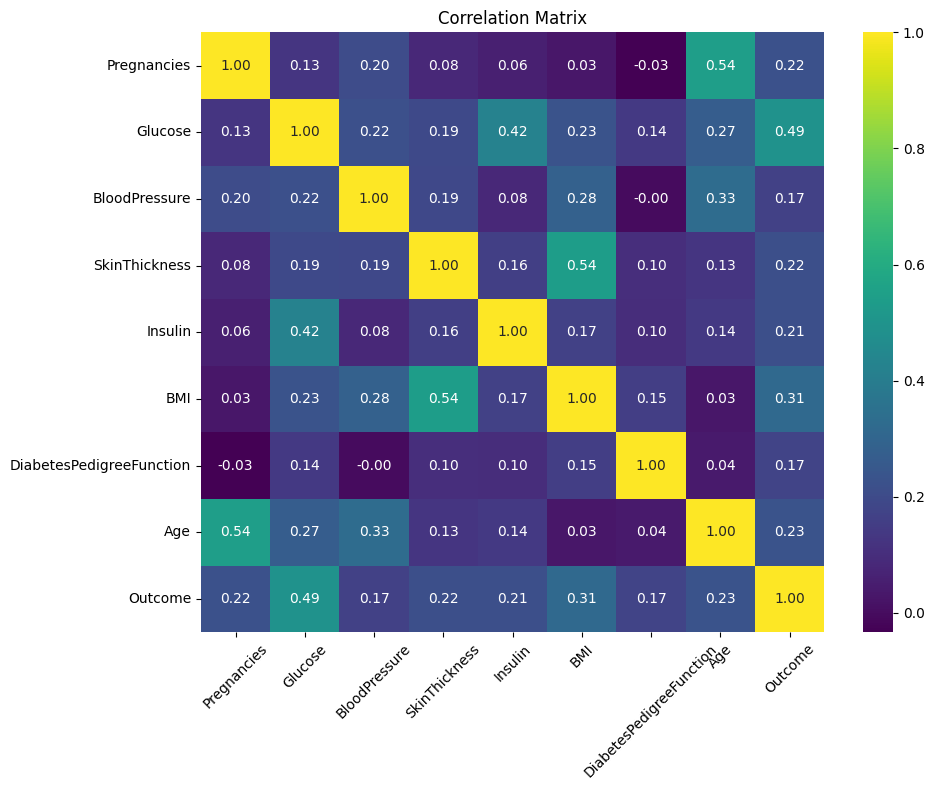

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(768, 9)

In [ ]:

# 1. Remove duplicates based on numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
df = df.drop_duplicates(subset=numeric_columns)

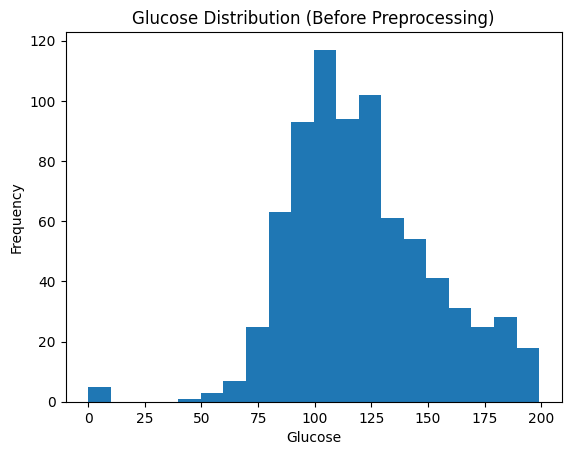

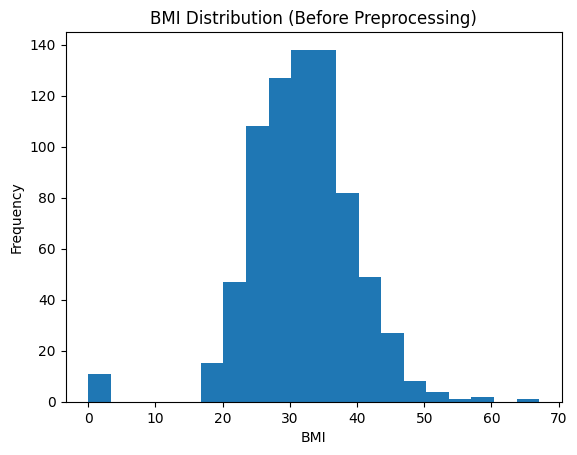

In [ ]:
#  VISUALIZATION BEFORE PREPROCESSING

# Histogram before preprocessing
plt.figure()
plt.hist(df["Glucose"], bins=20)
plt.title("Glucose Distribution (Before Preprocessing)")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()




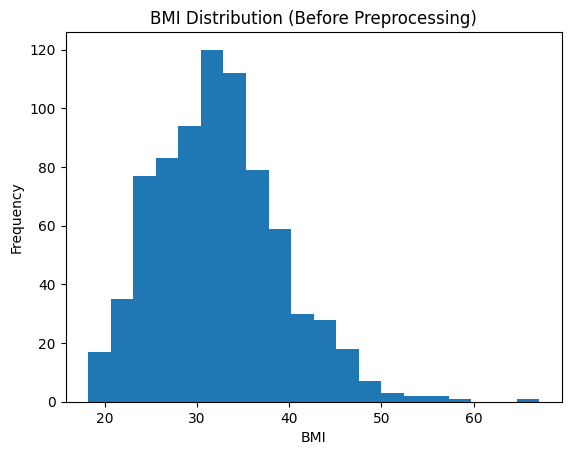

In [ ]:
plt.figure()
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution (Before Preprocessing)")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

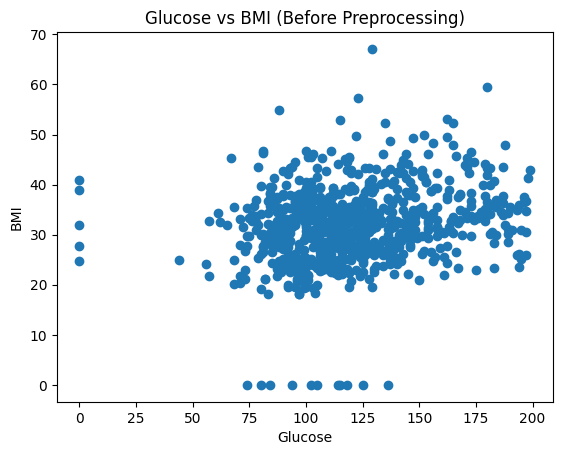

In [ ]:
# Scatter before preprocessing
plt.figure()
plt.scatter(df["Glucose"], df["BMI"])
plt.title("Glucose vs BMI (Before Preprocessing)")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()


In [ ]:
#  PREPROCESSING STEPS
# Step 1: Replace invalid zero values with NaN
medical_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[medical_columns] = df[medical_columns].replace(0, np.nan)


In [ ]:
# Step 2: Fill missing values with mean
df.fillna(df.mean(), inplace=True)

In [ ]:
# Step3 : Handling outliers using IQR for 'BMI' column
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)]
print("\nAfter Removing Outliers for BMI:\n", df_no_outliers)

# 5. Optional: Reset index after preprocessing
df_no_outliers.reset_index(drop=True, inplace=True)
print("\nFinal Cleaned Data (BMI outliers removed):\n", df_no_outliers)


After Removing Outliers for BMI:
      Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0              6    148.0           72.0       35.00000  155.548223  33.6   
1              1     85.0           66.0       29.00000  155.548223  26.6   
2              8    183.0           64.0       29.15342  155.548223  23.3   
3              1     89.0           66.0       23.00000   94.000000  28.1   
4              0    137.0           40.0       35.00000  168.000000  43.1   
..           ...      ...            ...            ...         ...   ...   
763           10    101.0           76.0       48.00000  180.000000  32.9   
764            2    122.0           70.0       27.00000  155.548223  36.8   
765            5    121.0           72.0       23.00000  112.000000  26.2   
766            1    126.0           60.0       29.15342  155.548223  30.1   
767            1     93.0           70.0       31.00000  155.548223  30.4   

     DiabetesPedigreeFunction   Age  Out

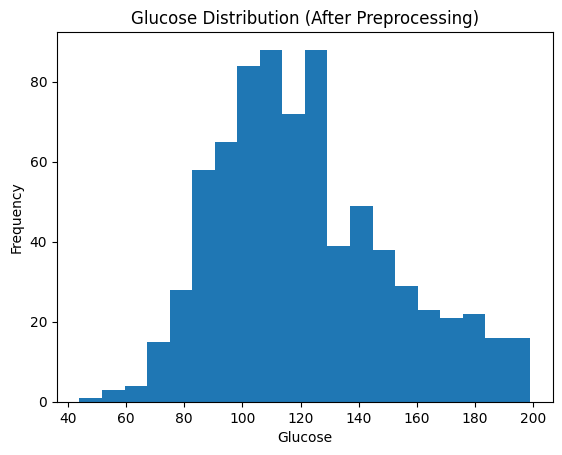

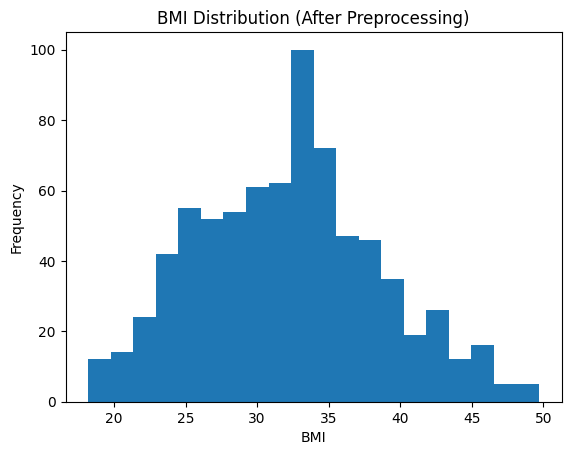

In [ ]:
#  VISUALIZATION AFTER PREPROCESSING

# Histogram after preprocessing
plt.figure()
plt.hist(df_no_outliers["Glucose"], bins=20)
plt.title("Glucose Distribution (After Preprocessing)")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df_no_outliers["BMI"], bins=20)
plt.title("BMI Distribution (After Preprocessing)")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

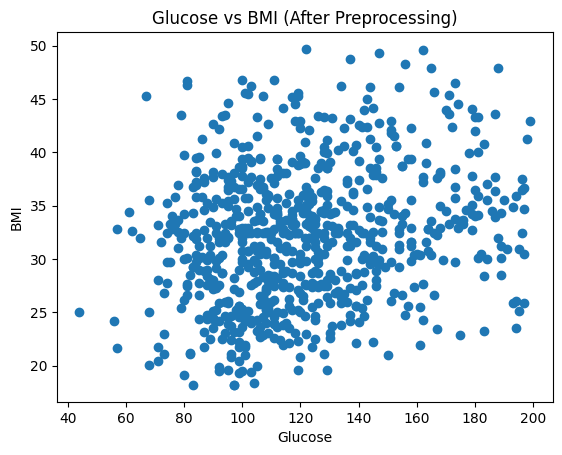

In [ ]:

# Scatter after preprocessing
plt.figure()
plt.scatter(df_no_outliers["Glucose"], df_no_outliers["BMI"])
plt.title("Glucose vs BMI (After Preprocessing)")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

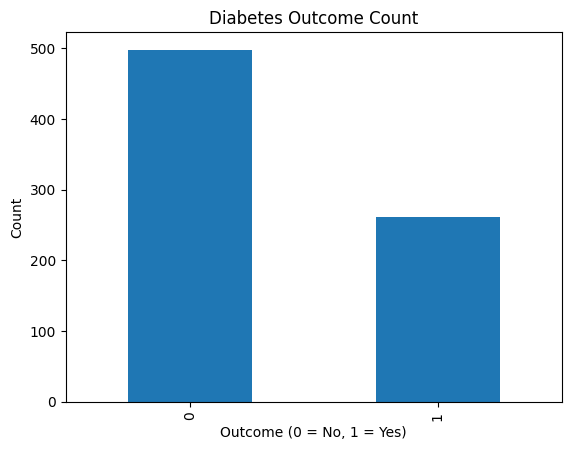

In [ ]:
# ADDITIONAL VISUALIZATIONS

# Outcome Count
plt.figure()
df_no_outliers["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

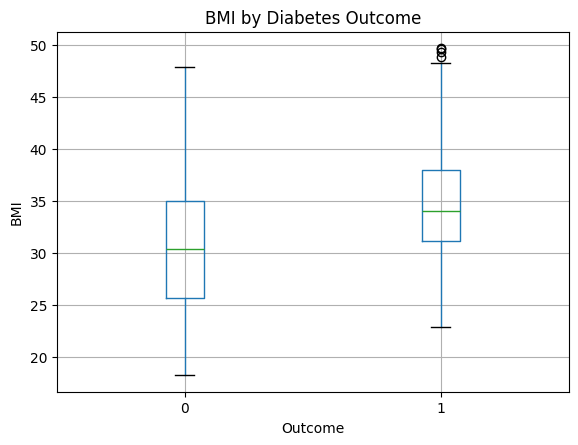

In [ ]:
# Boxplot BMI vs Outcome
plt.figure()
df_no_outliers.boxplot(column="BMI", by="Outcome")
plt.title("BMI by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.show()

In [ ]:
#  FINAL CHECK

print(df_no_outliers.isnull().sum())
print(df_no_outliers.info())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               759 non-null    int64  
 1   Glucose                   759 non-null    float64
 2   BloodPressure             759 non-null    float64
 3   SkinThickness             759 non-null    float64
 4   Insulin                   759 non-null    float64
 5   BMI                       759 non-null    float64
 6   DiabetesPedigreeFunction  759 non-null    float64
 7   Age                       759 non-null    float64
 8   Outcome                   759 non-null    int64  
dtypes: 